In [157]:
import numpy as np
from numpy import sqrt, zeros, ones, pi, linspace, sin, cos, tan, atan 
import matplotlib.pyplot as plt

### We wish to find the dispersions of electromagnetic modes supported by a metal-insulator interface (for which the metal has a nonlocal longitudinal permittivity). To this end, we use Eq. (11) of https://journals.aps.org/prb/pdf/10.1103/PhysRevB.88.115401 which we reiterate below (using the notation of this paper): 

$\begin{align*}
1+\frac{\varepsilon_m\kappa_d}{\varepsilon_d \kappa_m} +\delta_{nl}=0\rightarrow  
1+\frac{\varepsilon_m\kappa_d}{\varepsilon_d \kappa_m} + \frac{k^2}{\kappa_{m} \kappa_{nl}}(\varepsilon_m-1),
\end{align*}$

where the local permittivity of the metal, $\varepsilon_m$, and the wavenumbers $\kappa_{m}$, $\kappa_d$, $\kappa_{nl}$ are given by the following expressions: 

$\begin{align*}
&\varepsilon_m(\omega) = 1-\frac{\omega_p^2}{\omega^2+i\omega\gamma}=1-\frac{1}{\Omega(\Omega+i\Gamma)} \text{ where } \Omega\equiv \omega/\omega_p \text{ and } \Gamma\equiv \gamma/\omega_p
\\& \kappa_m = \sqrt{k^2-\varepsilon_m(\omega/c)^2} = (\omega_p/c)\sqrt{K^2-\varepsilon_m\Omega^2}, \text{  where }  K \equiv k c/\omega_p
\\& \kappa_d = \sqrt{k^2-\varepsilon_d(\omega/c)^2} = (\omega_p/c)\sqrt{K^2-\varepsilon_d\Omega^2}
\\&\kappa_{nl}=\sqrt{k^2-(\omega^2+i\gamma\omega-\omega_p^2)/\beta_F^2}=(\omega_p/c)\sqrt{K^2-(\Omega^2+i\Gamma\Omega-1)/\eta^2} \text{ where } \eta \equiv \beta_F/c
\end{align*}$

In [158]:
def return_epsilon_m(omega, gamma):
    return 1-1/(omega*(omega+1j*gamma))
def return_kappa_nl(k, omega, gamma, eta):
    return sqrt(k**2-(omega**2+1j*gamma*omega-1)/eta**2+ 0j)
def return_kappa_m(k, omega, gamma):
    return sqrt(k**2-return_epsilon_m(omega, gamma)*omega**2 + 0j)
def return_kappa_d(k, omega, epsilon_d):
    return sqrt(k**2-epsilon_d*omega**2+ 0j)

In [159]:
def equation_11(k, omega, gamma, eta, epsilon_d=1):
    epsilon_m = return_epsilon_m(omega, gamma)
    kappa_d = return_kappa_d(k, omega, epsilon_d)
    kappa_m = return_kappa_m(k, omega, gamma)
    kappa_nl = return_kappa_nl(k, omega, gamma, eta)

    kappa_d_real = kappa_d.real
    kappa_m_real = kappa_m.real
    kappa_nl_real = kappa_nl.real

    kappa_d_imag = kappa_d.imag
    kappa_m_imag = kappa_m.imag
    kappa_nl_imag = kappa_nl.imag

    #kappa_d = np.where(kappa_d_imag > 0, -kappa_d, kappa_d)
    #kappa_m = np.where(kappa_m_imag > 0, -kappa_m, kappa_m)
    #kappa_nl = np.where(kappa_nl_imag > 0, -kappa_nl, kappa_nl)

    return 1 + (epsilon_m*kappa_d)/(epsilon_d*kappa_m)+(epsilon_m-1)/(kappa_m*kappa_nl)

In [165]:
eta = 5e-3
N_k_real = 1000
N_k_imag = 1000
gamma = 0.1
#gamma = 1e-3
N_omega = 500
k_v_real = np.linspace(0, 6, N_k_real)
k_v_imag = np.linspace(0, 2, N_k_imag)
omega_v = np.linspace(0.5, 0.9, N_omega) # For gamma = 0.1
#omega_v = np.linspace(0.5, 0.725, N_omega) # For gamma = 0.01
k_mat_real = np.repeat(np.reshape(k_v_real, (N_k_real, 1)), N_k_imag, axis=1)
k_mat_imag = np.repeat(np.reshape(k_v_imag, (1, N_k_imag)), N_k_real, axis=0)

In [166]:
dispersion_k_real = zeros(N_omega)
dispersion_k_imag = zeros(N_omega)
for (omega_idx, omega) in enumerate(omega_v):
    dispersion_relation = equation_11(k_mat_real + 1j*k_mat_imag, omega*ones((N_k_real, N_k_imag)), gamma, eta)
    row, col = np.unravel_index(np.argmin(np.abs(dispersion_relation)), (N_k_real, N_k_imag))
    dispersion_k_real[omega_idx] = k_v_real[row]
    dispersion_k_imag[omega_idx] = k_v_imag[col]

### The cells below are a few of the subfigures of Figure 2 

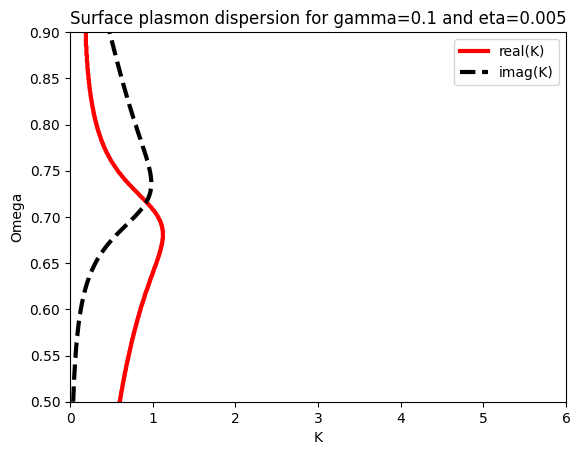

In [167]:
plt.plot(dispersion_k_real, omega_v, color="red", linewidth=3, label="real(K)")
plt.plot(dispersion_k_imag, omega_v, linestyle="dashed", color="black", linewidth=3, label="imag(K)")
plt.ylim(0.5, 0.9)
plt.xlim(0, 6);
plt.xlabel("K")
plt.ylabel("Omega")
plt.title(f"Surface plasmon dispersion for gamma={gamma} and eta={eta}")
plt.legend();

### The code below reproduces (hopefully) figures 1, 4, and 5 of the paper [Incoherent perfect absorption in lossy anisotropic materials](https://opg.optica.org/abstract.cfm?uri=oe-27-7-9561). Note that we define (in the notation of the linked paper) $\theta=\tan^{-1}(k_\tau/k_{n1})$, meaning $\theta$ is the angle from the  normal. For an isotropic medium, the absolute value of the p-polarized reflection coefficient will be given by the following:
$\begin{align*}
|r_p|=\Bigg|\frac{\varepsilon k_{n1}-k_{n2}}{\varepsilon k_{n1}+k_{n2}}\Bigg| = \Bigg|\frac{\varepsilon\cot(\theta)-\sqrt{\varepsilon\cot^2(\theta)+(\varepsilon-1)}}{\varepsilon\cot(\theta)+\sqrt{\varepsilon\cot^2(\theta)+(\varepsilon-1)}}\Bigg|=\Bigg|\frac{\varepsilon\cos(\theta)-\sqrt{\varepsilon-\sin^2(\theta)}}{\varepsilon\cos(\theta)+\sqrt{\varepsilon-\sin^2(\theta)}}\Bigg|
\end{align*}$,

where we used the following:

$\begin{align*}
&k_{n2}=\sqrt{\varepsilon(\omega/c)^2-k_\tau^2}=\sqrt{\varepsilon\Big[(\omega/c)^2-k_\tau^2 \Big]+(\varepsilon-1)k_\tau^2}
=k_\tau\sqrt{\varepsilon k_{n1}^2/k_\tau^2+(\varepsilon-1)}=k_\tau\sqrt{\varepsilon\cot^2(\theta)+(\varepsilon-1)}
\end{align*}$

Note that requiring the reflection coefficient to vanish immediately gives us the Brewster angle:

$\varepsilon^2-\sin^2(\theta)\varepsilon^2=\varepsilon-\sin^2(\theta)\rightarrow \varepsilon(\varepsilon-1)=\sin^2(\theta)(\varepsilon^2-1)\rightarrow \sin^2(\theta)=\varepsilon/(\varepsilon+1)$, $\cos^2(\theta)=1/(\varepsilon+1), \tan^2(\theta)=\varepsilon$

In [224]:
def r_p(epsilon, theta):
    k_n1 = cos(theta)
    k_n2 = sqrt(epsilon-sin(theta)**2)
    k_n2 = np.where(k_n2.imag < 0, -k_n2, k_n2)
    numerator = epsilon*k_n1 - k_n2
    denominator = epsilon*k_n1 + k_n2
    return np.abs(numerator/denominator)

In [225]:
N = 100000
angles = np.linspace(0, 90, N)
r_p_v_no_loss = r_p(2, angles*pi/180)
r_p_v_with_loss = r_p(2+2j, angles*pi/180)
brewster_angle = angles[np.argmin(r_p_v_no_loss)]

### Below is Figure 1 of the Narimanov paper

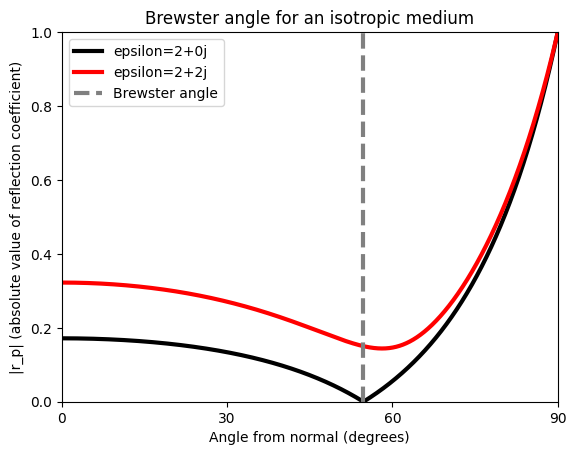

In [226]:
plt.plot(angles, r_p_v_no_loss, color="black", label="epsilon=2+0j", linewidth=3)
plt.plot(angles, r_p_v_with_loss, color="red", label="epsilon=2+2j", linewidth=3)
plt.vlines([brewster_angle], 0, 1, color="Grey", linestyle="dashed", linewidth=3, label="Brewster angle")
plt.ylim(0, 1)
plt.xlim(0, 90)
plt.yticks(linspace(0, 1, 6))
plt.xticks(linspace(0, 90, 4))
plt.legend();
plt.xlabel("Angle from normal (degrees)")
plt.ylabel("|r_p| (absolute value of reflection coefficient)")
plt.title("Brewster angle for an isotropic medium");

In [185]:
print("Brewster angle (in degrees): ", brewster_angle.round(3))
print("Brewster angle as predicted by formula: ", (atan(sqrt(2))*180/pi).round(3))

Brewster angle (in degrees):  54.736
Brewster angle as predicted by formula:  54.736


### Now we move on to anisotropic materials. In this case, the absolute value of the reflection coefficient is given by the following (again, in the notation of the Narimanov paper):

$\begin{align*}
|r_p| = \Bigg|\frac{k_{1n}\varepsilon_{2\tau}-k_{2n}}{k_{1n}\varepsilon_{2\tau}+k_{2n}}\Bigg|=\Bigg|\frac{\varepsilon_{2\tau}\cot(\theta)-k_{2n}/k_\tau}{\varepsilon_{2\tau}\cot(\theta)+k_{2n}/k_\tau} \Bigg|
\end{align*}$,

where $k_{2n}$ is given by the following expression:

$\begin{align*}
k_{2n}=\sqrt{\varepsilon_{2\tau}(\omega/c)^2-(\varepsilon_{2\tau}/\varepsilon_{2n})k_\tau^2}=\sqrt{\varepsilon_{2\tau}\Big[(\omega/c)^2-k_\tau^2\Big]+\varepsilon_{2\tau}\Big[1-1/\varepsilon_{2n}\Big]k_\tau^2}=k_\tau\sqrt{\varepsilon_{2\tau}\cot^2(\theta)+\varepsilon_{2\tau}(1-1/\varepsilon_{2n})}
\end{align*}$

In [190]:
def r_p_anisotropic(epsilon_tau, epsilon_n, theta):
    k_1n = 1/tan(theta)
    k_2n = sqrt(epsilon_tau/tan(theta)**2+epsilon_tau*(1-1/epsilon_n))
    k_2n = np.where(k_2n.imag < 0, -k_2n, k_2n)
    numerator = epsilon_tau*k_1n - k_2n 
    denominator = epsilon_tau*k_1n + k_2n
    return np.abs(numerator/denominator)

### First we check that this reduces to the isotropic case for $\varepsilon_{2n}=\varepsilon_{2n}$

In [194]:
N = 1000
angles = np.linspace(0.0001, 90-0.0001, N)
r_p_v_no_loss = r_p_anisotropic(2, 2, angles*pi/180)
brewster_angle = angles[np.argmin(r_p_v_no_loss)]

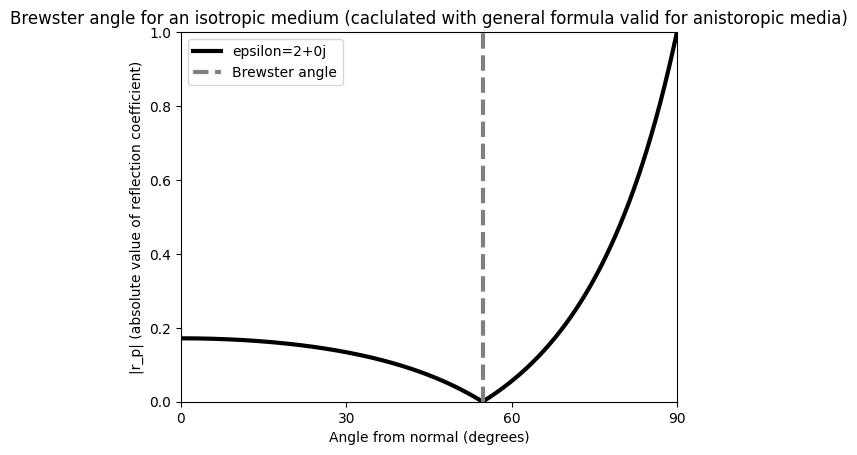

In [195]:
plt.plot(angles, r_p_v_no_loss, color="black", label="epsilon=2+0j", linewidth=3)
plt.vlines([brewster_angle], 0, 1, color="Grey", linestyle="dashed", linewidth=3, label="Brewster angle")
plt.ylim(0, 1)
plt.xlim(0, 90)
plt.legend();
plt.yticks(linspace(0, 1, 6))
plt.xticks(linspace(0, 90, 4))
plt.xlabel("Angle from normal (degrees)")
plt.ylabel("|r_p| (absolute value of reflection coefficient)")
plt.title("Brewster angle for an isotropic medium (caclulated with general formula valid for anistoropic media)");

### Now we check that we get a Brewster angle (zero reflection) for hBN for the two values of the permittivity given in Section 5 of the Narimanov paper: 

In [196]:
epsilon_n_1_hbn = 7.351 + 0.038j # For angular frequency of 611.7 cm^-1 
epsilon_tau_1_hbn = 6.794 + 0.0047j # For angular frequency of 611.7 cm^-1 

epsilon_n_2_hbn = 3.051 + 0.0159j # For angular frequency of 952.8 cm^-1
epsilon_tau_2_hbn = 8.084 + 0.0180j # For angular frequency of 952.8 cm^-1

In [197]:
N = 10000
angles = np.linspace(1e-4, 90-1e-4, N) # We avoid theta = 0 since we are diving by tangent in the above
r_p_v_hbn_1 = r_p_anisotropic(epsilon_tau_1_hbn, epsilon_n_1_hbn, angles*pi/180) # For angular frequency of 611.7 cm^-1 
r_p_v_hbn_2 = r_p_anisotropic(epsilon_tau_2_hbn, epsilon_n_2_hbn, angles*pi/180) # For angular frequency of 952.8 cm^-1

brewster_angle_hbn_1 = angles[np.argmin(r_p_v_hbn_1)]
print("Brewster angle for omega = 611.7 cm^-1 (in degrees): ", brewster_angle_hbn_1)

brewster_angle_hbn_2 = angles[np.argmin(r_p_v_hbn_2)]
print("Brewster angle for omega = 952.8 cm^-1 (in degrees): ", brewster_angle_hbn_2)

Brewster angle for omega = 611.7 cm^-1 (in degrees):  68.88383531353136
Brewster angle for omega = 952.8 cm^-1 (in degrees):  72.88022607260726


### Below is Figure 5 of the Narimanov paper

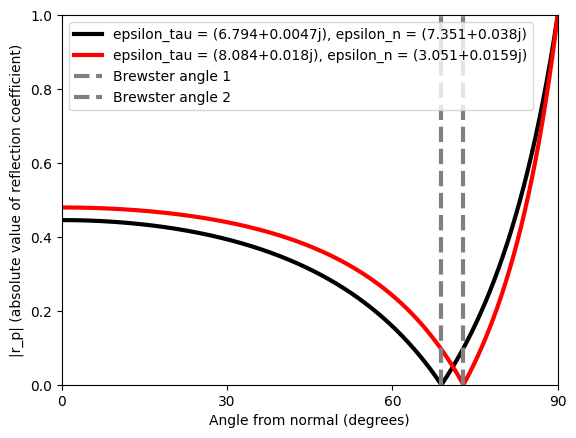

In [198]:
plt.plot(angles, r_p_v_hbn_1, color="black", label=f"epsilon_tau = {epsilon_tau_1_hbn}, epsilon_n = {epsilon_n_1_hbn}", linewidth=3)
plt.plot(angles, r_p_v_hbn_2, color="red", label=f"epsilon_tau = {epsilon_tau_2_hbn}, epsilon_n = {epsilon_n_2_hbn}", linewidth=3)
plt.vlines([brewster_angle_hbn_1], 0, 90, color="Grey", label="Brewster angle 1", linewidth=3, linestyle="dashed")
plt.vlines([brewster_angle_hbn_2], 0, 90, color="Grey", label="Brewster angle 2", linewidth=3, linestyle="dashed")
plt.yticks(linspace(0, 1, 6))
plt.xticks(linspace(0, 90, 4))
plt.xlabel("Angle from normal (degrees)")
plt.ylabel("|r_p| (absolute value of reflection coefficient)")
plt.ylim(0, 1)
plt.xlim(0, 90)
plt.legend();

### Below, we check that the Brewster angles make sense from an analytic formul

In [199]:
for (epsilon_n, epsilon_tau) in zip((epsilon_n_1_hbn, epsilon_n_2_hbn), (epsilon_tau_1_hbn, epsilon_tau_2_hbn)):
    k_tau_sqrd = epsilon_n * (1-epsilon_tau)/(1-epsilon_n*epsilon_tau)
    k_n_1_sqrd = 1-k_tau_sqrd
    brewster_angle = atan(sqrt(k_tau_sqrd/k_n_1_sqrd))*180/pi
    print("Brewster angle: ", brewster_angle.real)

Brewster angle:  68.88577815853456
Brewster angle:  72.87839849222968


### Now we do the same calculation for Sapphire ($\text{Al}_2\text{O}_3$), again at two different frequencies for which the material properties are conducive to a real valued Brewster angle. We also plot the reflection for "fake" version of Sapphire that is isotropic to see how much the anisotropicity helps lower the reflectivity. 

In [200]:
epsilon_n_1_sapphire = -1.474 + 0.146j  #For angular frequency of 503.46 cm^-1 
epsilon_tau_1_sapphire = 8.326 + 0.292j #For angular frequency of 503.46 cm^-1 
epsilon_n_2_sapphire = 2.099 + 0.079j # For angular frequency of 520.93 cm^-1
epsilon_tau_2_sapphire = 15.274 + 0.491j # For angular frequency of 520.93 cm^-1

In [201]:
N = 100000
angles = np.linspace(1e-4, 90-1e-4, N) # We avoid theta = 0 since we are diving by tangent in the above
r_p_v_sapphire_1 = r_p_anisotropic(epsilon_tau_1_sapphire, epsilon_n_1_sapphire, angles*pi/180) # For angular frequency of 503.46 cm^-1 
r_p_v_sapphire_15 = r_p_anisotropic(epsilon_tau_1_sapphire, epsilon_tau_1_sapphire, angles*pi/180) # For angular frequency of 503.46 cm^-1 
r_p_v_sapphire_2 = r_p_anisotropic(epsilon_tau_2_sapphire, epsilon_n_2_sapphire, angles*pi/180) # For angular frequency of 520.93 cm^-1

brewster_angle_sapphire_1 = angles[np.argmin(r_p_v_sapphire_1)]
print("Brewster angle for omega=503.46 cm^-1 (in degrees): ", brewster_angle_sapphire_1)

brewster_angle_sapphire_2 = angles[np.argmin(r_p_v_sapphire_2)]
print("Brewster angle for omega=520.93 cm^-1 (in degrees): ", brewster_angle_sapphire_2)

Brewster angle for omega=503.46 cm^-1 (in degrees):  64.465801401014
Brewster angle for omega=520.93 cm^-1 (in degrees):  79.15121562115621


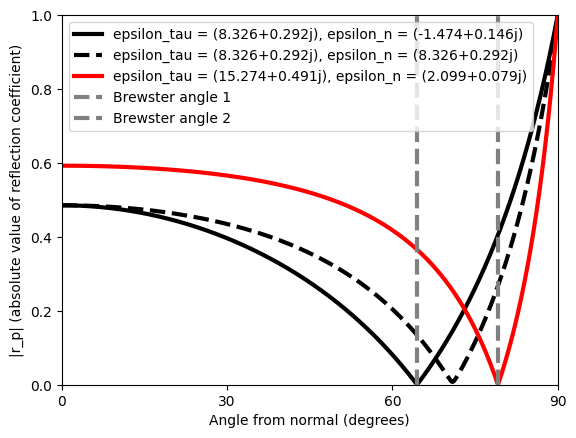

In [202]:
plt.plot(angles, r_p_v_sapphire_1, color="black", label=f"epsilon_tau = {epsilon_tau_1_sapphire}, epsilon_n = {epsilon_n_1_sapphire}", linewidth=3)
plt.plot(angles, r_p_v_sapphire_15, color="black", label=f"epsilon_tau = {epsilon_tau_1_sapphire}, epsilon_n = {epsilon_tau_1_sapphire}", linewidth=3, linestyle="dashed")
plt.plot(angles, r_p_v_sapphire_2, color="red", label=f"epsilon_tau = {epsilon_tau_2_sapphire}, epsilon_n = {epsilon_n_2_sapphire}", linewidth=3)
plt.vlines([brewster_angle_sapphire_1], 0, 90, color="Grey", label="Brewster angle 1", linewidth=3, linestyle="dashed")
plt.vlines([brewster_angle_sapphire_2], 0, 90, color="Grey", label="Brewster angle 2", linewidth=3, linestyle="dashed")
plt.yticks(linspace(0, 1, 6))
plt.xticks(linspace(0, 90, 4))
plt.xlabel("Angle from normal (degrees)")
plt.ylabel("|r_p| (absolute value of reflection coefficient)")
plt.ylim(0, 1)
plt.xlim(0, 90)
plt.legend();

### The ratio printed below shows how much the anistropic nature of sapphire helps in lowering the reflectivity

In [203]:
(r_p_v_sapphire_15.min()/r_p_v_sapphire_1.min()).item()

647.2123347801346

### Below, we check that the Brewster angles make sense from an analytic formula

In [204]:
for (epsilon_n, epsilon_tau) in zip((epsilon_n_1_sapphire, epsilon_n_2_sapphire), (epsilon_tau_1_sapphire, epsilon_tau_2_sapphire)):
    k_tau_sqrd = epsilon_n * (1-epsilon_tau)/(1-epsilon_n*epsilon_tau)
    k_n_1_sqrd = 1-k_tau_sqrd
    brewster_angle = atan(sqrt(k_tau_sqrd/k_n_1_sqrd))*180/pi
    print("Brewster angle: ", brewster_angle.real)

Brewster angle:  64.46580885079936
Brewster angle:  79.1510980679051


### We now check how the reflectivity of a metal changes as loss is increased 

In [258]:
epsilon_real = 2
N_imag = 10
epsilon_imag_v = np.linspace(0, 6, N_imag)
N = 10000
r_p_v_v = []
angles = np.linspace(1e-4, 90-1e-4, N) # We avoid theta = 0 since we are diving by tangent in the above
for epsilon_imag in epsilon_imag_v:
    r_p_v_v.append(r_p(epsilon_real + 1j*epsilon_imag, angles*pi/180))

Minimum reflectivity corresponds to angle:  54.734  for epsilon_imag=0.0
Minimum reflectivity corresponds to angle:  55.13  for epsilon_imag=0.667
Minimum reflectivity corresponds to angle:  56.355  for epsilon_imag=1.333
Minimum reflectivity corresponds to angle:  58.119  for epsilon_imag=2.0
Minimum reflectivity corresponds to angle:  60.027  for epsilon_imag=2.667
Minimum reflectivity corresponds to angle:  61.845  for epsilon_imag=3.333
Minimum reflectivity corresponds to angle:  63.492  for epsilon_imag=4.0
Minimum reflectivity corresponds to angle:  64.941  for epsilon_imag=4.667
Minimum reflectivity corresponds to angle:  66.229  for epsilon_imag=5.333
Minimum reflectivity corresponds to angle:  67.354  for epsilon_imag=6.0


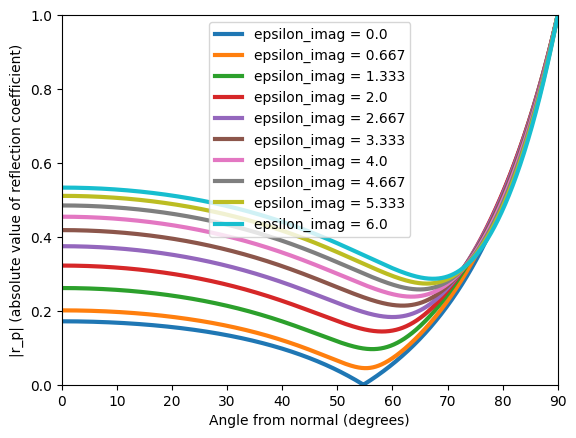

In [265]:
for (epsilon_imag, r_p_v) in zip(epsilon_imag_v, r_p_v_v):
    plt.plot(angles, r_p_v, label=f"epsilon_imag = {epsilon_imag.round(3)}", linewidth=3)
    print("Minimum reflectivity corresponds to angle: ", angles[r_p_v.argmin()].round(3), f" for epsilon_imag={epsilon_imag.round(3)}")
plt.ylim(0, 1)
plt.legend();
plt.xlim(0, 90);
plt.xlabel("Angle from normal (degrees)")
plt.ylabel("|r_p| (absolute value of reflection coefficient)");

### We now calculate the Brewster angle in the presence of spatial nonlocality. We take the incident field above the nonlocal material, the reflected field above the nonlocal material, and the transmitted field in the nonlocal material to be given by the following expressions: 

$\begin{align*}
&\Big(\sqrt{(\omega/c)^2-k_\tau^2}, k_\tau\Big)e^{ik_\tau x}e^{-i\sqrt{(\omega/c)^2-k_\tau^2} z} \text{ for the incident field } \\
&r_p\Big(-\sqrt{(\omega/c)^2-k_\tau^2}, k_\tau\Big)e^{ik_\tau x}e^{i\sqrt{(\omega/c)^2-k_\tau^2} z}  \text{ for the reflected field } \\ 
&t_p\Big(\Big(\sqrt{\varepsilon_m(\omega/c)^2-k_\tau^2}, k_\tau\Big)e^{ik_\tau x}e^{i\sqrt{\varepsilon_m(\omega/c)^2-k_\tau^2} z}  + \alpha\Big(k_\tau, -\sqrt{k_{nl}^2-k_\tau^2}\Big) e^{ik_\tau x}e^{-i\sqrt{k_{nl}^2-k_\tau^2}z}\Big)
\end{align*}$

### Our boundary conditions then give us the following three expressions:
$\begin{align*}
&(1-r_p)q_1=(q_2+\alpha k_\tau)t_p \text{ (BC 1) }
\\& (1+r_p)=\varepsilon_m t_p \text{ (BC 2) }
\\& k_\tau(1+r_p)=(k_\tau-\alpha q_{nl})t_p \text{ (BC 3) }
\end{align*}$

### From these boundary conditions we obtain the following relation: 
$\begin{align*}
(1-r_p)q_1\varepsilon_m q_{nl}=(1+r_p)(q_2q_{nl} +k_\tau^2(1-\varepsilon_m))
\end{align*}$

### Therefore the reflection coefficient is given by the following (defining $q_1\equiv \sqrt{(\omega/c)^2-k_\tau^2}, q_2\equiv \sqrt{\varepsilon_m(\omega/c)^2-k_\tau^2}, q_{nl}\equiv \sqrt{k_{nl}^2-k_\tau^2}$): 

$\begin{align*}
\frac{q_2q_{nl}+k_\tau^2(1-\varepsilon_m)-q_1q_{nl}\varepsilon_m}{(\varepsilon_m-1)k_\tau^2-q_2q_{nl}-\varepsilon_mq_1q_{nl}} =
-\frac{q_2+k_\tau^2(1-\varepsilon_m)/q_{nl}-q_1\varepsilon_m}{(1-\varepsilon_m)k_\tau^2/q_{nl}+q_2+\varepsilon_mq_1}=\frac{q_1\varepsilon_m-q_2(1+k_\tau^2(1-\varepsilon_m)/(q_{nl}q_2))}{q_2(1+(1-\varepsilon_m)k_\tau^2/(q_{nl}q_2))+\varepsilon_mq_1}  
\end{align*}$

### Note that the last expression is equivalent to **Equation 1a** of the following paper: https://www.nature.com/articles/srep02526.pdf. We now check that the above is consistent with the requirement that the normal component of the current vanish at the interface: 

$\begin{align*}
&-i\omega\varepsilon_0\nabla\cdot\mathbf{E}+\nabla\cdot\mathbf{J}=0 \rightarrow \mathbf{J}=\sigma(\omega)\mathbf{E}-\frac{\beta_F^2(i\omega\varepsilon_0)}{\omega(\omega+i\eta)}\nabla(\nabla\cdot\mathbf{E})=-i\omega\varepsilon_0\Bigg[(\varepsilon_m-1)\mathbf{E}+\frac{\beta_F^2}{\omega(\omega+i\eta)}\nabla(\nabla\cdot\mathbf{E}) \Bigg] \\&\rightarrow J_z= (\varepsilon_m-1)(k_\tau-\alpha q_{nl})+\alpha q_{nl}\frac{k_{nl}^2\beta_F^2}{\omega^2+i\omega\eta}= (\varepsilon_m-1)(k_\tau-\alpha q_{nl})+\alpha q_{nl}\frac{\omega^2+i\omega\eta-\omega_p^2}{\omega^2+i\omega\eta}=(\varepsilon_m-1)(k_\tau-\alpha q_{nl})+\alpha q_{nl}\varepsilon_m
\end{align*}$

### Therefore, requiring $J_z=0$ gives us the following:

$(\varepsilon_m-1)k_\tau+\alpha q_{nl}=0 \text{ (BC 4) } $

### Note that (BC 4) follows immediately from (BC 2) and (BC 3); meaning, (BC 4) is not an independent boundary condition. 

### We now write the nonlocal reflection coefficient in terms of the angle using the following relations:

$(\omega/c)^2-k_\tau^2=k_\tau^2\cot^2(\theta)\rightarrow (\omega/c)^2=k_\tau^2/\sin^2(\theta)$

$(\omega^2+i\omega\gamma-\omega_p^2)/\beta_F^2=(1/\eta^2)(\omega/c)^2(1+i(\gamma\omega_p)/(\omega_p\omega)-\omega_p^2/\omega^2)=
(1/\eta^2)(k_\tau^2/\sin^2(\theta))(1+i\Gamma/\Omega -1/\Omega^2)$

### This gives us the following expression for the reflection coefficient: 

$\begin{align*}
\frac{\sqrt{\frac{1}{\eta^2}(1+i\Gamma/\Omega-1/\Omega^2)-\sin^2(\theta)}\Big[\cos(\theta)\varepsilon_m-\sqrt{\varepsilon_m-\sin^2(\theta)}\Big]+ (\varepsilon_m-1)\sin^2(\theta)}{\sqrt{\frac{1}{\eta^2}(1+i\Gamma/\Omega-1/\Omega^2)-\sin^2(\theta)}\Big[\cos(\theta)\varepsilon_m+\sqrt{\varepsilon_m-\sin^2(\theta)}\Big]-(\varepsilon_m-1)\sin^2(\theta)}
\end{align*}$

In [205]:
def r_p_drude(omega, gamma, theta):
    epsilon = 1 - 1/(omega*(omega+1j*gamma))
    q_1 = cos(theta)
    q_2 = sqrt(epsilon-sin(theta)**2)
    q_2 = np.where(q_2.imag < 0, -q_2, q_2)
    numerator = epsilon*q_1 - q_2
    denominator = epsilon*q_1 + q_2
    return np.abs(numerator/denominator)

def r_p_nonlocal_drude(omega, gamma, eta, theta):
    epsilon = 1 - 1/(omega*(omega+1j*gamma))
    k_nl_sqrd = (1/eta**2)*(1+1j*gamma/omega-1/omega**2)
    kappa_nl = sqrt(k_nl_sqrd-sin(theta)**2)
    q_1 = cos(theta) 
    q_2 = sqrt(epsilon-sin(theta)**2)
    q_2 = np.where(q_2.imag < 0, -q_2, q_2)
    kappa_nl = np.where(kappa_nl.imag < 0, -kappa_nl, kappa_nl)
    
    numerator = kappa_nl*epsilon*q_1 - kappa_nl*q_2 + (epsilon-1)*sin(theta)**2
    denominator = kappa_nl*epsilon*q_1 + kappa_nl*q_2 - (epsilon-1)*sin(theta)**2
    return np.abs(numerator/denominator)

In [206]:
N = 1000000
angles = np.linspace(89.9, 90, N)
r_p_v = r_p_drude(1e-6, 1e-3, angles*pi/180)
r_p_v_nonlocal = r_p_nonlocal_drude(1e-6, 1e-3, 20, angles*pi/180)

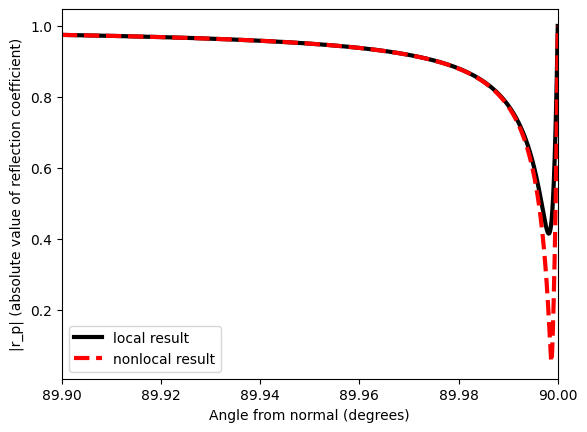

In [212]:
plt.plot(angles, r_p_v, linewidth=3, color="black", label="local result")
plt.plot(angles, r_p_v_nonlocal, linewidth=3, linestyle="dashed", color="red", label="nonlocal result")
plt.legend();

plt.xlim(angles.min(), angles.max());
plt.xlabel("Angle from normal (degrees)")
plt.ylabel("|r_p| (absolute value of reflection coefficient)");

### We now augment the results above by including diffusion, which means making the following substitution: 

$\begin{align*}
&(\beta/c)^2\rightarrow (\beta/c)^2+(\gamma/\omega_p)(D\omega_p/c^2)-i(\omega/\omega_p)(D\omega_p/c^2)
\end{align*}$

We take $D\approx v_F^2/\gamma \rightarrow D\omega_p/c^2\approx (v_F/c)^2(\omega_p/\gamma)$

### See these references for more information: https://www.nature.com/articles/ncomms4809.pdf, https://iopscience.iop.org/article/10.1088/1361-648X/ab977d/pdf?casa_token=2XVUIOBFrNAAAAAA:Hje6d0_twZfvPwIuXNgBFh0pmUD-jadXarv6DrLe4FC6-sAHje-WHaEjohUkMYaQqygKC7p-fSEqqyv7FqqtbfRghPE

In [286]:
def r_p_nonlocal_diffusion_drude(omega, gamma, v_F, theta):
    eta_sqrd = 3/5*v_F**2 + (v_F**2/gamma)*(gamma-1j*omega)
    epsilon = 1 - 1/(omega*(omega+1j*gamma))
    k_nl_sqrd = (1/eta_sqrd)*(1+1j*gamma/omega-1/omega**2)
    kappa_nl = sqrt(k_nl_sqrd-sin(theta)**2)
    kappa_nl = np.where(kappa_nl.imag < 0, -kappa_nl, kappa_nl)

    q_1 = cos(theta)
    q_2 = sqrt(epsilon-sin(theta)**2)
    q_2 = np.where(q_2.imag < 0, -q_2, q_2)

    numerator = kappa_nl*epsilon*q_1 - kappa_nl*q_2 + (epsilon-1)*sin(theta)**2
    denominator = kappa_nl*epsilon*q_1 + kappa_nl*q_2 - (epsilon-1)*sin(theta)**2
    return np.abs(numerator/denominator)

In [288]:
N = 10000
angles = np.linspace(1, 90, N)
v_F = 1e-2
omega = 0.707
gamma = 5e-5
r_p_v = r_p_drude(omega, gamma, angles*pi/180)
r_p_v_nonlocal_diffusion = r_p_nonlocal_diffusion_drude(omega, gamma, v_F, angles*pi/180)
r_p_v_nonlocal = r_p_nonlocal_drude(omega, gamma, sqrt(3/5) * v_F, angles*pi/180)

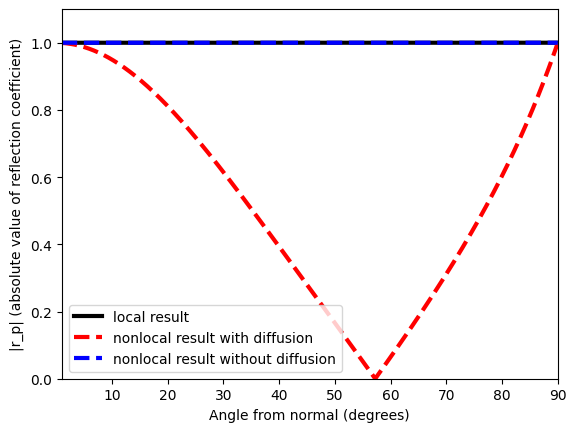

In [289]:
plt.plot(angles, r_p_v, linewidth=3, color="black", label="local result")
plt.plot(angles, r_p_v_nonlocal_diffusion, linewidth=3, linestyle="dashed", color="red", label="nonlocal result with diffusion")
plt.plot(angles, r_p_v_nonlocal, linewidth=3, linestyle="dashed", color="blue", label="nonlocal result without diffusion")

plt.ylim(0, 1.1)
plt.xlim(angles.min(), angles.max());
plt.xlabel("Angle from normal (degrees)")
plt.legend();
plt.ylabel("|r_p| (absolute value of reflection coefficient)");

In [295]:
N_omegas = 2000
N_angles = 2000
angles = linspace(88, 90, N_angles)
angles_mat = np.repeat(np.reshape(angles, (N_angles, 1)), N_omegas, axis=1)
v_F = 1e-2
omegas = linspace(0.01, 0.03, N_omegas)
omegas_mat = np.repeat(np.reshape(omegas, (1, N_omegas)), N_angles, axis=0)
gamma = 1e-6
r_p_v_nonlocal_diffusion = r_p_nonlocal_diffusion_drude(omegas_mat, gamma, v_F, angles_mat*pi/180)
r_p_v_nonlocal = r_p_nonlocal_drude(omegas_mat, gamma, sqrt(3/5)*v_F, angles_mat*pi/180)
r_p_v_local = r_p_drude(omegas_mat, gamma, angles_mat*pi/180)

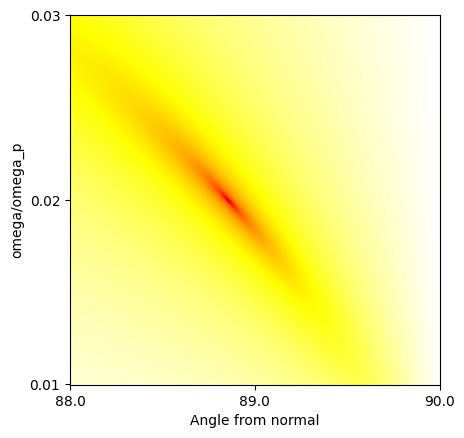

In [312]:
plt.imshow(np.log(r_p_v_nonlocal_diffusion).T, cmap="hot", origin="lower")
xticks = [1, 1000, 1999]
yticks = [1, 1000, 1999]

plt.xticks(xticks, angles[xticks].round(2));
plt.yticks(yticks, omegas[yticks].round(2));
plt.ylabel("omega/omega_p")
plt.xlabel("Angle from normal");

In [319]:
brewster_omega = omegas_mat.flatten()[r_p_v_nonlocal_diffusion.argmin()]

In [322]:
N_angles = 2000
angles = linspace(88, 90, N_angles)
v_F = 1e-2
gamma = 1e-6
r_p_v_nonlocal_diffusion = r_p_nonlocal_diffusion_drude(brewster_omega, gamma, v_F, angles*pi/180)

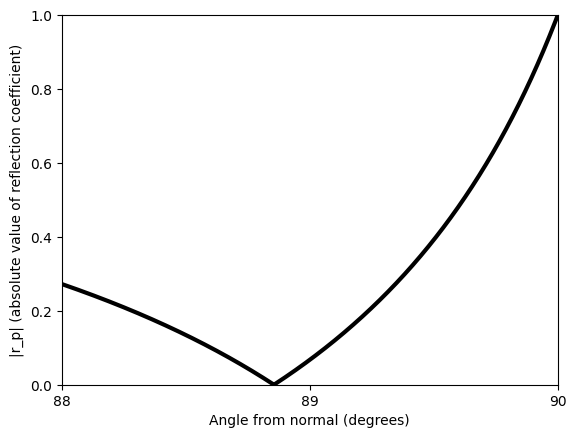

In [329]:
plt.plot(angles, r_p_v_nonlocal_diffusion, color="black", linewidth=3)
plt.xticks([88, 89, 90])
plt.xlim(angles.min(), angles.max());
plt.ylim(0, 1);
plt.xlabel("Angle from normal (degrees)");
plt.ylabel("|r_p| (absolute value of reflection coefficient)");